#### 00 - Dependencies

In [1]:
import os

os.environ["LLM_API_KEY"] = os.environ.get("LLM_API_KEY", "")
os.environ["LLM_BASE_URL"] = os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1")
os.environ["LLM_MODEL"] = os.environ.get("LLM_MODEL", "openai/gpt-4o-mini")
os.environ["LLM_TEMPERATURE"] = os.environ.get("LLM_TEMPERATURE", "0")

#### 1.0 - Data

- load
- split
- embed

In [2]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

url = "https://claude.com/blog/millennium-and-anthropic-are-building-a-digital-risk-analyst-with-claude"
classes = ["u-rich-text-blog u-margin-trim w-richtext"]
loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(class_=tuple(classes))),
)
docs = loader.load()
print(len(docs), "documents loaded from the web page")

/var/folders/2r/0xf5r35d0t1330pv9d7lrq1c0000gn/T/ipykernel_39331/1689528646.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


1 documents loaded from the web page


In [3]:
import langchain
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0,
    length_function=len,
)
splits = text_splitter.split_documents(docs)
print(len(splits), "splits created from the documents")

4 splits created from the documents


In [4]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = OpenAIEmbeddings(
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=embeddings)
retriever = vectorstore.as_retriever()

#### 2.0 - Retrieve and Generate

- prompt
- llm
- graph

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

prompt_template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(prompt_template)

llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

In [18]:
from typing import Literal
from pydantic import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant handler."""

    datasource: Literal["vectorstore", "general"] = Field(
        ...,
        description=(
            "Use 'vectorstore' for questions about 'Millennium and Anthropic are building a digital risk analyst with Claude' and 'general' "
            "for anything else."
        ),
    )

router_prompt_template = """Decide whether the user is asking about this new topic of anthropics about 'Millennium and Anthropic are building a digital risk analyst with Claude' or not. 
Only return vectorstore if it is and general otherwise.
"""
router_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", router_prompt_template),
            ("human", "{question}"),
        ]
    )

router_llm = llm.with_structured_output(RouteQuery)

In [23]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.documents import Document

class RAGState(TypedDict):   
    question: str
    route: str
    context: List[Document]
    answer: str

def route_question(state: RAGState) -> RAGState:
    messages = router_prompt.invoke({"question": state["question"]})
    decision: RouteQuery = router_llm.invoke(messages)
    return {"route": decision.datasource}

def general(state: RAGState) -> RAGState:
    messages = prompt.invoke({                  
        "context": "probably out of context or a general question.",
        "question": state["question"],
    })
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else response.content}

def retrieve(state: RAGState) -> RAGState:
    docs = retriever.invoke(state["question"])
    return {"context": docs}

def generate(state: RAGState) -> RAGState:
    context_str = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"context": context_str, "question":
state["question"]})
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else
response.content}            

def out_of_scope(state: RAGState) -> RAGState:
    return {"answer": "Sorry — I can only answer questions about the Millennium × Anthropic digital risk analyst announcement."}

def pick_branch(state: RAGState) -> Literal["retrieve", "general"]:
    return "retrieve" if state["route"] == "vectorstore" else "general"


builder = StateGraph(RAGState)
builder.add_node("router", route_question)
builder.add_node("general", general)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_edge(START, "router")
builder.add_conditional_edges("router", pick_branch, {
    "retrieve": "retrieve",
    "general": "general",                       
})
builder.add_edge("retrieve", "generate")
builder.add_edge("general", END)
builder.add_edge("generate", END)

graph = builder.compile()

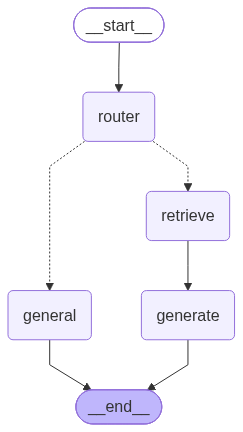

In [24]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [21]:
result = graph.invoke({"question": "What is Millennium and Anthropic building together?"})
result["answer"]

"Millennium and Anthropic are building a digital risk analyst, which is an AI teammate designed to work alongside and under the supervision of Millennium's risk managers to surface new risk insights and form opinions on risk exposure across asset classes."

In [25]:
greeting_result = graph.invoke({"question": "Hello, how are you?"})
greeting_result["answer"]

"I'm just a program, so I don't have feelings, but I'm here to help you! How can I assist you today?"